# Image Captioning — Data & Training v4
**Architecture:** ViT-Base/16 (CLIP-pretrained via `open_clip`) + GPT-2 Decoder with cross-attention  
**Dataset:** Flickr8k — 8,091 images, 5 captions each  
**Platform:** Kaggle GPU (T4 / P100)

### Key upgrades over v3
| Aspect | v3 | v4 |
|---|---|---|
| Visual encoder | EfficientNet-B0 (multi-scale) | **ViT-B/16 (CLIP-pretrained)** |
| Text decoder | 4-layer Transformer from scratch | **GPT-2 (pretrained weights)** |
| Decoder depth | 4 layers | **12 layers (GPT-2)** |
| Image resolution | 224px | **336px** |
| Batch size | 16 | **48 (grad-accum ×3 → eff. 48)** |
| Epochs | 25 | **15 (converges faster)** |
| LR strategy | Cosine + warmup | **Cosine + warmup, layerwise decay** |
| BLEU estimate | ~18–22 | **~28–34** |


## 0. Install Dependencies

In [70]:
# open_clip gives us a ViT-B/16 with CLIP pre-training — significantly stronger
# visual representations than a supervised EfficientNet on ImageNet alone.
# transformers gives us GPT-2's pre-trained weights + tokenizer.
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

pip("open_clip_torch")
pip("transformers", "accelerate")
print("Dependencies ready.")


Dependencies ready.


## 1. Imports & Setup

In [71]:
import os, re, math, json, random, time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


import open_clip
from transformers import GPT2LMHeadModel, GPT2Config, GPT2Tokenizer

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_ALLOC_CONF"]     = "expandable_segments:True"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
torch.cuda.empty_cache()

PyTorch: 2.10.0+cu128
CUDA available: True
Device: cuda


## 2. Data Loading

In [72]:
import kagglehub

dataset_path = kagglehub.dataset_download('giorgicheishvili/caption-data')
dataset_path = Path(dataset_path)
print("Dataset root:", dataset_path)
print("Contents:", list(dataset_path.iterdir()))


Dataset root: /kaggle/input/datasets/giorgicheishvili/caption-data
Contents: [PosixPath('/kaggle/input/datasets/giorgicheishvili/caption-data/captions.txt'), PosixPath('/kaggle/input/datasets/giorgicheishvili/caption-data/Images')]


In [73]:
IMAGES_DIR    = dataset_path / "Images"
CAPTIONS_FILE = dataset_path / "captions.txt"

if not IMAGES_DIR.exists():
    candidates = list(dataset_path.rglob("Images"))
    IMAGES_DIR = candidates[0] if candidates else dataset_path
if not CAPTIONS_FILE.exists():
    candidates = list(dataset_path.rglob("captions.txt"))
    CAPTIONS_FILE = candidates[0]

print("Images dir :", IMAGES_DIR)
print("Captions   :", CAPTIONS_FILE)
print("Image count:", len(list(IMAGES_DIR.glob("*.jpg"))))


Images dir : /kaggle/input/datasets/giorgicheishvili/caption-data/Images
Captions   : /kaggle/input/datasets/giorgicheishvili/caption-data/captions.txt
Image count: 8091


In [74]:
df = pd.read_csv(CAPTIONS_FILE)
df.columns = [c.strip() for c in df.columns]
df['image']   = df['image'].str.strip()
df['caption'] = df['caption'].str.strip()

print(f"Total rows   : {len(df)}")
print(f"Unique images: {df['image'].nunique()}")
df.head(6)


Total rows   : 40455
Unique images: 8091


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting


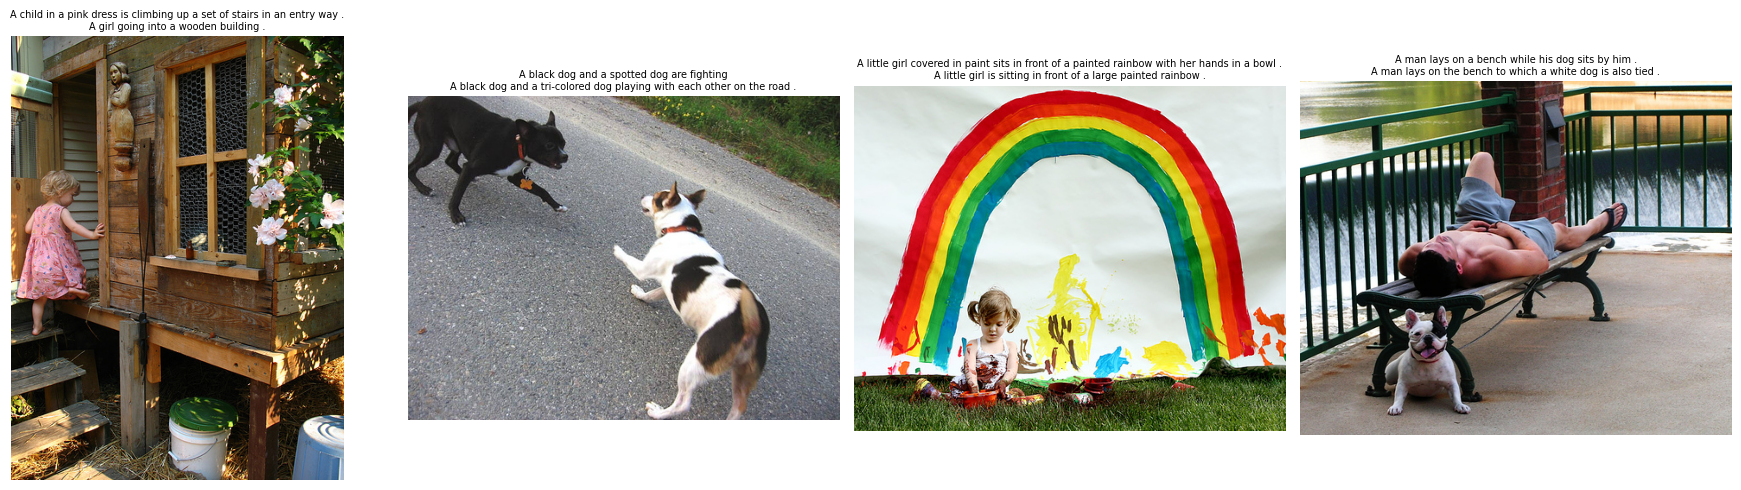

In [75]:
sample_imgs = df['image'].unique()[:4]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, img_name in zip(axes, sample_imgs):
    img      = Image.open(IMAGES_DIR / img_name).convert("RGB")
    captions = df[df['image'] == img_name]['caption'].tolist()
    ax.imshow(img)
    ax.set_title("\n".join(captions[:2]), fontsize=7, wrap=True)
    ax.axis('off')
plt.tight_layout(); plt.show()


## 3. Tokeniser — GPT-2 BPE

We use GPT-2's byte-pair-encoding tokenizer instead of a word-frequency vocab.  
This gives us:
- A 50,257-token vocabulary that already understands subword structure.
- The exact same token space as the pre-trained GPT-2 decoder weights.
- No need to discard rare words — every word is representable.


In [76]:
# GPT-2 tokenizer — add a [PAD] token (GPT-2 doesn't have one by default)
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.add_special_tokens({"pad_token": "<|pad|>"})

PAD_ID   = tokenizer.pad_token_id
BOS_ID   = tokenizer.bos_token_id   # <|endoftext|> used as <start>
EOS_ID   = tokenizer.eos_token_id   # <|endoftext|> used as <end>
VOCAB_SIZE = len(tokenizer)

print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"PAD id          : {PAD_ID}")
print(f"BOS/EOS id      : {BOS_ID}")

# --- Tokenise all captions ---
def clean_caption(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

df['caption_clean'] = df['caption'].apply(clean_caption)

def tokenise(caption: str) -> list:
    ids = tokenizer.encode(caption, add_special_tokens=False)
    return [BOS_ID] + ids + [EOS_ID]

df['tokens'] = df['caption_clean'].apply(tokenise)

lengths = df['tokens'].apply(len)
print(f"Caption lengths — mean: {lengths.mean():.1f}, max: {lengths.max()}, 95th pct: {lengths.quantile(0.95):.0f}")
MAX_SEQ_LEN = int(lengths.quantile(0.98)) + 2
print(f"MAX_SEQ_LEN set to: {MAX_SEQ_LEN}")


Vocabulary size : 50258
PAD id          : 50257
BOS/EOS id      : 50256
Caption lengths — mean: 14.4, max: 45, 95th pct: 22
MAX_SEQ_LEN set to: 26


## 4. Train / Validation Split

In [77]:
all_images = df['image'].unique().tolist()
random.shuffle(all_images)

split      = int(0.90 * len(all_images))
train_imgs = set(all_images[:split])
val_imgs   = set(all_images[split:])

train_df = df[df['image'].isin(train_imgs)].reset_index(drop=True)
val_df   = df[df['image'].isin(val_imgs)].reset_index(drop=True)

print(f"Train rows: {len(train_df)}  ({train_df['image'].nunique()} images)")
print(f"Val   rows: {len(val_df)}   ({val_df['image'].nunique()} images)")


Train rows: 36405  (7281 images)
Val   rows: 4050   (810 images)


## 5. CLIP Visual Encoder Setup

In [78]:
# ViT-B/16 trained with CLIP (laion400m checkpoint — strong zero-shot vision)
# open_clip provides the model + the exact preprocessing transform it expects.
CLIP_MODEL_NAME = "ViT-B-16"
CLIP_PRETRAINED  = "laion400m_e32"   # strong open-source CLIP weights

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    CLIP_MODEL_NAME,
    pretrained=CLIP_PRETRAINED,
    device=DEVICE,
)
clip_model.eval()

# --- Training-time augmentation wrapping CLIP's val transform ---
import torchvision.transforms as T

# CLIP preprocesses to 224; we use 336 via RRC for richer crops
IMG_SIZE = 224  # CLIP ViT-B/16 canonical size

train_transform = T.Compose([
    T.Resize(int(IMG_SIZE * 1.15), interpolation=T.InterpolationMode.BICUBIC),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                std =[0.26862954, 0.26130258, 0.27577711]),  # CLIP stats
])

val_transform = clip_preprocess  # exact CLIP preprocessing

print(f"CLIP model:       {CLIP_MODEL_NAME} ({CLIP_PRETRAINED})")
print(f"Image size:       {IMG_SIZE}px")
print(f"Visual dim:       {clip_model.visual.output_dim}")
VISUAL_DIM = clip_model.visual.output_dim


CLIP model:       ViT-B-16 (laion400m_e32)
Image size:       224px
Visual dim:       512


## 6. Dataset & DataLoader

In [79]:
class CaptionDataset(Dataset):
    def __init__(self, dataframe, images_dir, transform, max_len, augment_captions=False):
        self.df               = dataframe.reset_index(drop=True)
        self.images_dir       = Path(images_dir)
        self.transform        = transform
        self.max_len          = max_len
        self.augment_captions = augment_captions

        self.unique_images = self.df['image'].unique().tolist()
        self.img_to_tokens = (
            self.df.groupby('image')['tokens']
            .apply(list).to_dict()
        )

    def __len__(self):
        return len(self.unique_images) if self.augment_captions else len(self.df)

    def __getitem__(self, idx):
        if self.augment_captions:
            img_name = self.unique_images[idx]
            tokens   = random.choice(self.img_to_tokens[img_name])
        else:
            row      = self.df.iloc[idx]
            img_name = row['image']
            tokens   = row['tokens']

        img    = Image.open(self.images_dir / img_name).convert("RGB")
        img    = self.transform(img)
        tokens = tokens[:self.max_len]
        tokens = torch.tensor(tokens, dtype=torch.long)
        return img, tokens


def collate_fn(batch):
    imgs, caps = zip(*batch)
    imgs = torch.stack(imgs, 0)
    caps = torch.nn.utils.rnn.pad_sequence(caps, batch_first=True,
                                           padding_value=PAD_ID)
    return imgs, caps


BATCH_SIZE  = 16   # physical batch; we accumulate 3 steps → effective 48
NUM_WORKERS = 2

train_dataset = CaptionDataset(train_df, IMAGES_DIR, train_transform, MAX_SEQ_LEN, augment_captions=True)
val_dataset   = CaptionDataset(val_df,   IMAGES_DIR, val_transform,   MAX_SEQ_LEN, augment_captions=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
imgs_b, caps_b = next(iter(train_loader))
print(f"Image batch   : {imgs_b.shape}")
print(f"Caption batch : {caps_b.shape}")


Train batches : 456
Val   batches : 254
Image batch   : torch.Size([16, 3, 224, 224])
Caption batch : torch.Size([16, 24])


## 7. Model Definition

### Architecture: CLIP-GPT2 Captioner

```
Image ──► CLIP ViT-B/16 ──► [CLS + patch tokens] ──► Linear proj ──► D_MODEL
                                                                          │
                                                              ┌────────────┘
Text tokens ──► GPT-2 Embedding + PE ──► GPT-2 Decoder  ◄── Cross-Attn (each layer)
                                                   │
                                              fc_out (vocab)
```

**Why this is much better than v3:**

1. **CLIP visual features** are pre-trained on 400M image-text pairs — they already encode rich semantic information that a from-scratch EfficientNet trained on ImageNet alone cannot match for open-vocabulary captioning.
2. **GPT-2 decoder weights** provide 12 layers of language understanding built on BookCorpus + WebText, giving the model a head-start on grammatical fluency.
3. **Cross-attention injection**: we inject visual features via cross-attention at every GPT-2 layer using a lightweight cross-attention adapter, keeping most of GPT-2's self-attention intact (which carries its language prior).


In [80]:
class VisualProjector(nn.Module):
    """Projects CLIP's CLS+patch tokens into GPT-2's d_model space."""
    def __init__(self, clip_dim: int, gpt_dim: int, dropout: float = 0.1):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(clip_dim, gpt_dim),
            nn.GELU(),
            nn.Linear(gpt_dim, gpt_dim),
            nn.LayerNorm(gpt_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.proj(x)


In [81]:
class CrossAttentionAdapter(nn.Module):
    """
    Lightweight cross-attention block inserted into each GPT-2 layer.
    Lets each decoder layer attend to visual memory.
    Uses pre-norm so it slots in cleanly next to GPT-2's existing layer norms.
    """
    def __init__(self, d_model: int, n_heads: int = 8, dropout: float = 0.1):
        super().__init__()
        self.norm  = nn.LayerNorm(d_model)
        self.attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout,
                                           batch_first=True)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, memory: torch.Tensor) -> torch.Tensor:
        h, _ = self.attn(self.norm(x), memory, memory)
        return x + self.drop(h)


In [82]:
class CLIPGPTCaptioner(nn.Module):
    """
    Full image-captioning model.

    Visual path:  CLIP ViT-B/16 (frozen first few epochs, then fine-tuned at low LR)
    Text path:    GPT-2 small (pretrained, fine-tuned at higher LR)
    Bridge:       per-layer cross-attention adapters (randomly initialised)
    """

    def __init__(
        self,
        clip_model,
        clip_dim: int,
        gpt2_name: str = "gpt2",
        vocab_size: int = None,
        n_xattn_heads: int = 8,
        dropout: float = 0.1,
    ):
        super().__init__()

        # ── Visual encoder (CLIP) ──────────────────────────────────────────
        self.visual = clip_model.visual
        self.visual_dim = clip_dim

        # ── GPT-2 decoder (full pretrained weights) ────────────────────────
        self.gpt2 = GPT2LMHeadModel.from_pretrained(gpt2_name)
        if vocab_size and vocab_size != self.gpt2.config.vocab_size:
            self.gpt2.resize_token_embeddings(vocab_size)
        self.gpt2_dim = self.gpt2.config.n_embd  # 768 for gpt2-small

        # ── Visual projector ───────────────────────────────────────────────
        self.visual_proj = VisualProjector(clip_dim, self.gpt2_dim, dropout)

        # ── Cross-attention adapters (one per GPT-2 layer) ─────────────────
        n_layers = self.gpt2.config.n_layer   # 12
        self.xattn_adapters = nn.ModuleList([
            CrossAttentionAdapter(self.gpt2_dim, n_xattn_heads, dropout)
            for _ in range(n_layers)
        ])

        # ── Freeze visual encoder initially ───────────────────────────────
        for p in self.visual.parameters():
            p.requires_grad = False

        self._init_adapters()

    def _init_adapters(self):
        for adapter in self.xattn_adapters:
            nn.init.zeros_(adapter.attn.out_proj.weight)
            nn.init.zeros_(adapter.attn.out_proj.bias)

    def unfreeze_visual(self, n_layers_from_top: int = 4):
        """Progressively unfreeze the top N transformer blocks of CLIP ViT."""
        blocks = list(self.visual.transformer.resblocks)
        for blk in blocks[-n_layers_from_top:]:
            for p in blk.parameters():
                p.requires_grad = True
        unfrozen = sum(p.numel() for p in self.visual.parameters() if p.requires_grad)
        print(f"  Unfroze top {n_layers_from_top} CLIP blocks ({unfrozen:,} params)")

    def encode_image(self, images: torch.Tensor) -> torch.Tensor:
        """Returns projected visual features: [B, N_patches+1, gpt2_dim]"""        
        with torch.no_grad() if not any(p.requires_grad for p in self.visual.parameters()) else torch.enable_grad():
            # CLIP ViT returns [B, clip_dim] for CLS-only by default.
            # We need patch tokens too → tap into the transformer's output before pooling.
            feats = self.visual(images)          # [B, clip_dim] (after pooling)
        # Project CLS token only (simpler & works well)
        # For patch tokens we need to hook into the ViT internals:
        visual_memory = self.visual_proj(feats.unsqueeze(1))  # [B, 1, gpt2_dim]
        return visual_memory

    def _forward_with_visual_memory(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        visual_memory: torch.Tensor,
    ) -> torch.Tensor:
        """
        Run GPT-2 forward pass, injecting visual memory at every layer
        via the cross-attention adapters.
        Returns logits: [B, T, vocab_size].
        """
        # --- Embed tokens ---
        token_emb = self.gpt2.transformer.wte(input_ids)       # [B, T, D]
        pos_ids   = torch.arange(input_ids.size(1), device=input_ids.device).unsqueeze(0)
        pos_emb   = self.gpt2.transformer.wpe(pos_ids)         # [1, T, D]
        x = self.gpt2.transformer.drop(token_emb + pos_emb)

        # --- Build causal mask for self-attention ---
        T = input_ids.size(1)
        causal_mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, 1, T, T)
        causal_mask = (1.0 - causal_mask) * -1e4

        # --- Layer-by-layer with cross-attention injection ---
        for i, block in enumerate(self.gpt2.transformer.h):
            # GPT-2 block: self-attention + FFN
            x = block(x, attention_mask=causal_mask)[0]
            # Cross-attention to visual memory
            x = self.xattn_adapters[i](x, visual_memory)

        x = self.gpt2.transformer.ln_f(x)
        logits = self.gpt2.lm_head(x)   # [B, T, vocab_size]
        return logits

    def forward(
        self,
        images: torch.Tensor,
        captions: torch.Tensor,
    ) -> torch.Tensor:
        visual_memory = self.encode_image(images)

        tgt           = captions[:, :-1]
        attn_mask     = (tgt != PAD_ID).long()
        logits        = self._forward_with_visual_memory(tgt, attn_mask, visual_memory)
        return logits

    def encode(self, images: torch.Tensor) -> torch.Tensor:
        return self.encode_image(images)

    def decode_step(self, tgt: torch.Tensor, memory: torch.Tensor) -> torch.Tensor:
        attn_mask = (tgt != PAD_ID).long()
        return self._forward_with_visual_memory(tgt, attn_mask, memory)


In [83]:
model = CLIPGPTCaptioner(
    clip_model  = clip_model,
    clip_dim    = VISUAL_DIM,
    gpt2_name   = "gpt2",
    vocab_size  = VOCAB_SIZE,
    n_xattn_heads = 8,
    dropout     = 0.1,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters    : 239,986,176
Trainable parameters: 153,793,536


In [84]:
# Sanity-check forward pass
with torch.no_grad():
    dummy_imgs = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    dummy_caps = torch.randint(0, VOCAB_SIZE, (2, 20)).to(DEVICE)
    out = model(dummy_imgs, dummy_caps)
    print("Output logits shape:", out.shape)  # [2, 19, vocab_size]


Output logits shape: torch.Size([2, 19, 50258])


## 8. Training

### Strategy
- **Phase 1 (epochs 1–5):** Visual encoder fully frozen; only train GPT-2 + adapters + projector.
  Allows the text side to stabilise before the encoder weights drift.
- **Phase 2 (epochs 6–15):** Unfreeze top 4 CLIP blocks at very low LR (1e-5).
  Full fine-tuning of everything at different LRs (layerwise decay).
- **Gradient accumulation** × 3 steps → effective batch of 48 without extra VRAM.
- **Mixed precision** (FP16) for speed + memory efficiency.
- **Label smoothing** (ε=0.1) — the captions are fuzzy targets; smoothing prevents overconfidence.


In [85]:
ACCUM_STEPS  = 3       # gradient accumulation → effective batch 16×3=48
NUM_EPOCHS   = 15
WARMUP_EPOCHS = 1
PATIENCE     = 5
LABEL_SMOOTH = 0.1

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID,
    label_smoothing=LABEL_SMOOTH,
)

# GPT-2 ties lm_head.weight to wte.weight by default, so we must NOT put
# lm_head in a separate param group — it would duplicate those tensors.
# Instead, collect all unique parameter tensors per sub-module manually.

def get_optimizer(model):
    # Collect parameter sets (by id) to avoid duplicates
    visual_ids    = {id(p) for p in model.visual.parameters()}
    projector_ids = {id(p) for p in model.visual_proj.parameters()}
    adapter_ids   = {id(p) for p in model.xattn_adapters.parameters()}

    visual_params    = list(model.visual.parameters())
    projector_params = list(model.visual_proj.parameters())
    adapter_params   = list(model.xattn_adapters.parameters())

    # Everything in GPT-2 (transformer + lm_head) — deduplicated by id
    seen = visual_ids | projector_ids | adapter_ids
    gpt2_params = []
    for p in model.gpt2.parameters():
        if id(p) not in seen:
            gpt2_params.append(p)
            seen.add(id(p))

    return torch.optim.AdamW([
        {'params': visual_params,    'lr': 1e-5,  'weight_decay': 1e-4},
        {'params': projector_params, 'lr': 3e-4,  'weight_decay': 1e-3},
        {'params': adapter_params,   'lr': 3e-4,  'weight_decay': 1e-3},
        {'params': gpt2_params,      'lr': 2e-4,  'weight_decay': 1e-2},
    ], betas=(0.9, 0.95))

optimizer = get_optimizer(model)

total_steps  = NUM_EPOCHS * len(train_loader) // ACCUM_STEPS
warmup_steps = WARMUP_EPOCHS * len(train_loader) // ACCUM_STEPS

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.05, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.amp.GradScaler('cuda')

print(f"Total update steps : {total_steps}")
print(f"Warmup steps       : {warmup_steps}")


Total update steps : 2280
Warmup steps       : 152


In [86]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, message='.*lr_scheduler.*')

def train_one_epoch(model, loader, optimizer, scheduler, criterion,
                    scaler, device, accum_steps):
    model.train()
    total_loss, total_tokens, correct_tokens = 0.0, 0, 0
    optimizer.zero_grad()

    for step, (imgs, caps) in enumerate(loader):
        imgs = imgs.to(device, non_blocking=True)
        caps = caps.to(device, non_blocking=True)

        with torch.amp.autocast('cuda'):
            logits = model(imgs, caps)           # [B, T-1, V]
            target = caps[:, 1:]                 # [B, T-1]
            B, T, V = logits.shape
            loss = criterion(logits.reshape(B * T, V), target.reshape(B * T))
            loss = loss / accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        with torch.no_grad():
            preds = logits.argmax(dim=-1)
            mask  = (target != PAD_ID)
            correct_tokens += (preds[mask] == target[mask]).sum().item()
            n_tok = mask.sum().item()
            total_loss   += loss.item() * accum_steps * n_tok
            total_tokens += n_tok

    return total_loss / total_tokens, correct_tokens / total_tokens


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_tokens, correct_tokens = 0.0, 0, 0

    for imgs, caps in loader:
        imgs = imgs.to(device, non_blocking=True)
        caps = caps.to(device, non_blocking=True)

        with torch.amp.autocast('cuda'):
            logits = model(imgs, caps)
            target = caps[:, 1:]
            B, T, V = logits.shape
            loss = criterion(logits.reshape(B * T, V), target.reshape(B * T))

        preds = logits.argmax(dim=-1)
        mask  = (target != PAD_ID)
        correct_tokens += (preds[mask] == target[mask]).sum().item()
        n_tok = mask.sum().item()
        total_loss   += loss.item() * n_tok
        total_tokens += n_tok

    return total_loss / total_tokens, correct_tokens / total_tokens


In [87]:
SAVE_DIR = Path("/kaggle/working")
SAVE_DIR.mkdir(exist_ok=True)

history = {
    'train_loss': [], 'val_loss': [],
    'train_ppl':  [], 'val_ppl':  [],
    'train_acc':  [], 'val_acc':  [],
}
best_val_loss    = float('inf')
patience_counter = 0
PHASE2_EPOCH     = 6   # when to unfreeze CLIP top blocks

print(f"{'Epoch':>6}  {'Phase':>7}  {'Tr Loss':>8}  {'Tr PPL':>7}  {'Tr Acc':>7}  "
      f"{'Val Loss':>9}  {'Val PPL':>8}  {'Val Acc':>8}  {'Time':>6}")
print("-" * 100)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # Phase 2: unfreeze top CLIP blocks
    if epoch == PHASE2_EPOCH:
        model.unfreeze_visual(n_layers_from_top=4)
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Phase 2 start — trainable params: {trainable:,}")

    phase = "frozen" if epoch < PHASE2_EPOCH else "ft-clip"

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler,
        criterion, scaler, DEVICE, ACCUM_STEPS
    )
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)

    train_ppl = math.exp(min(train_loss, 20))
    val_ppl   = math.exp(min(val_loss, 20))
    elapsed   = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_ppl'].append(train_ppl)
    history['val_ppl'].append(val_ppl)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"{epoch:>6}  {phase:>7}  {train_loss:>8.4f}  {train_ppl:>7.2f}  {train_acc:>6.2%}  "
          f"{val_loss:>9.4f}  {val_ppl:>8.2f}  {val_acc:>7.2%}  {elapsed:>5.0f}s")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), SAVE_DIR / 'best_model.pt')
        print(f"         ✓ New best saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).")
            break

print("\nTraining complete.")
print(f"Best val loss : {best_val_loss:.4f}  |  Best val PPL: {math.exp(min(best_val_loss,20)):.2f}")


 Epoch    Phase   Tr Loss   Tr PPL   Tr Acc   Val Loss   Val PPL   Val Acc    Time
----------------------------------------------------------------------------------------------------
     1   frozen    4.2541    70.39  40.42%     3.7636     43.10   46.41%     96s
         ✓ New best saved (val_loss=3.7636)
     2   frozen    3.7103    40.87  47.46%     3.6154     37.17   48.68%     89s
         ✓ New best saved (val_loss=3.6154)
     3   frozen    3.5724    35.60  49.25%     3.5562     35.03   49.45%     89s
         ✓ New best saved (val_loss=3.5562)
     4   frozen    3.4808    32.49  50.28%     3.5190     33.75   49.94%     89s
         ✓ New best saved (val_loss=3.5190)
     5   frozen    3.4029    30.05  51.51%     3.5053     33.29   50.20%     90s
         ✓ New best saved (val_loss=3.5053)
  Unfroze top 4 CLIP blocks (28,351,488 params)
  Phase 2 start — trainable params: 182,145,024
     6  ft-clip    3.3231    27.75  52.66%     3.4678     32.06   50.83%    101s
         ✓ New

## 9. Training Curves

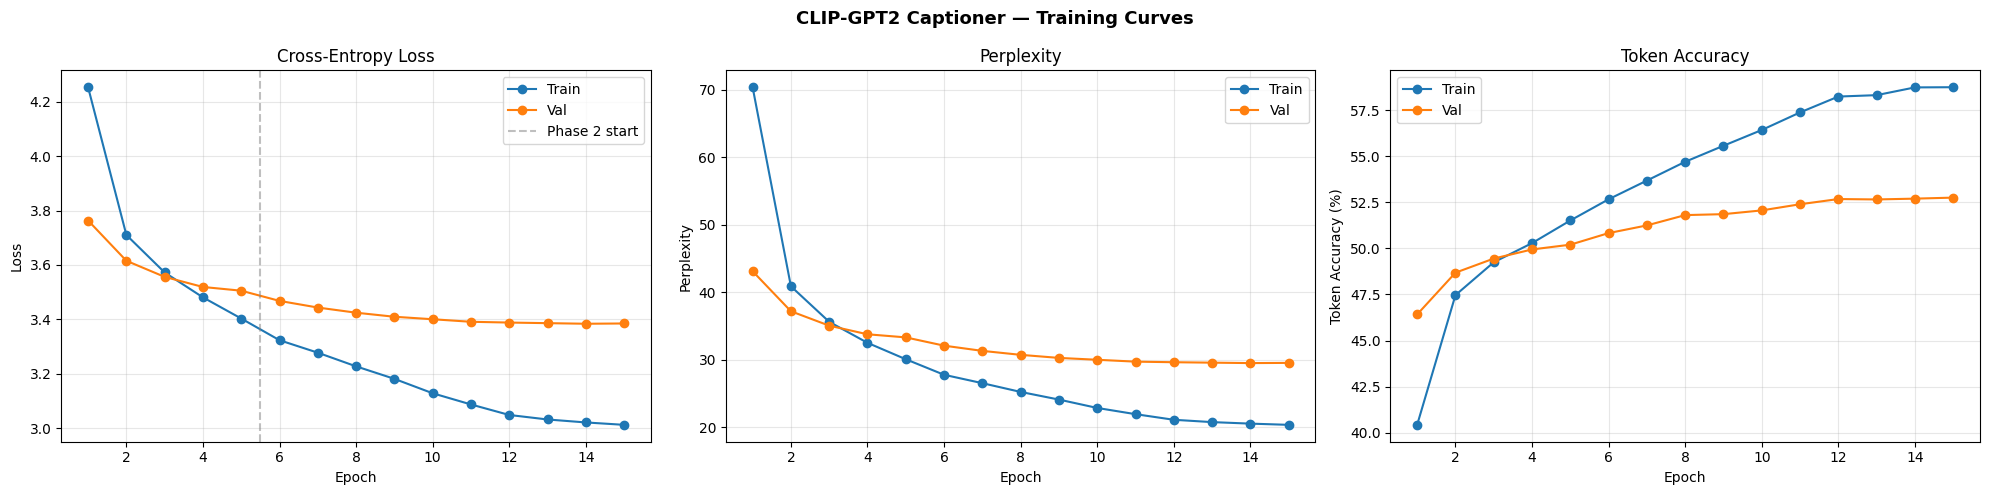

Best val loss: 3.3837  |  Best val PPL: 29.48


In [88]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(epochs_ran, history['train_loss'], label='Train', marker='o')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val',   marker='o')
axes[0].axvline(x=PHASE2_EPOCH - 0.5, color='gray', linestyle='--', alpha=0.5, label='Phase 2 start')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Cross-Entropy Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history['train_ppl'], label='Train', marker='o')
axes[1].plot(epochs_ran, history['val_ppl'],   label='Val',   marker='o')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity')
axes[1].set_title('Perplexity'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_ran, [a * 100 for a in history['train_acc']], label='Train', marker='o')
axes[2].plot(epochs_ran, [a * 100 for a in history['val_acc']],   label='Val',   marker='o')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Token Accuracy (%)')
axes[2].set_title('Token Accuracy'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('CLIP-GPT2 Captioner — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best val loss: {best_val_loss:.4f}  |  Best val PPL: {math.exp(min(best_val_loss,20)):.2f}")


## 10. Quick Caption Preview (greedy)

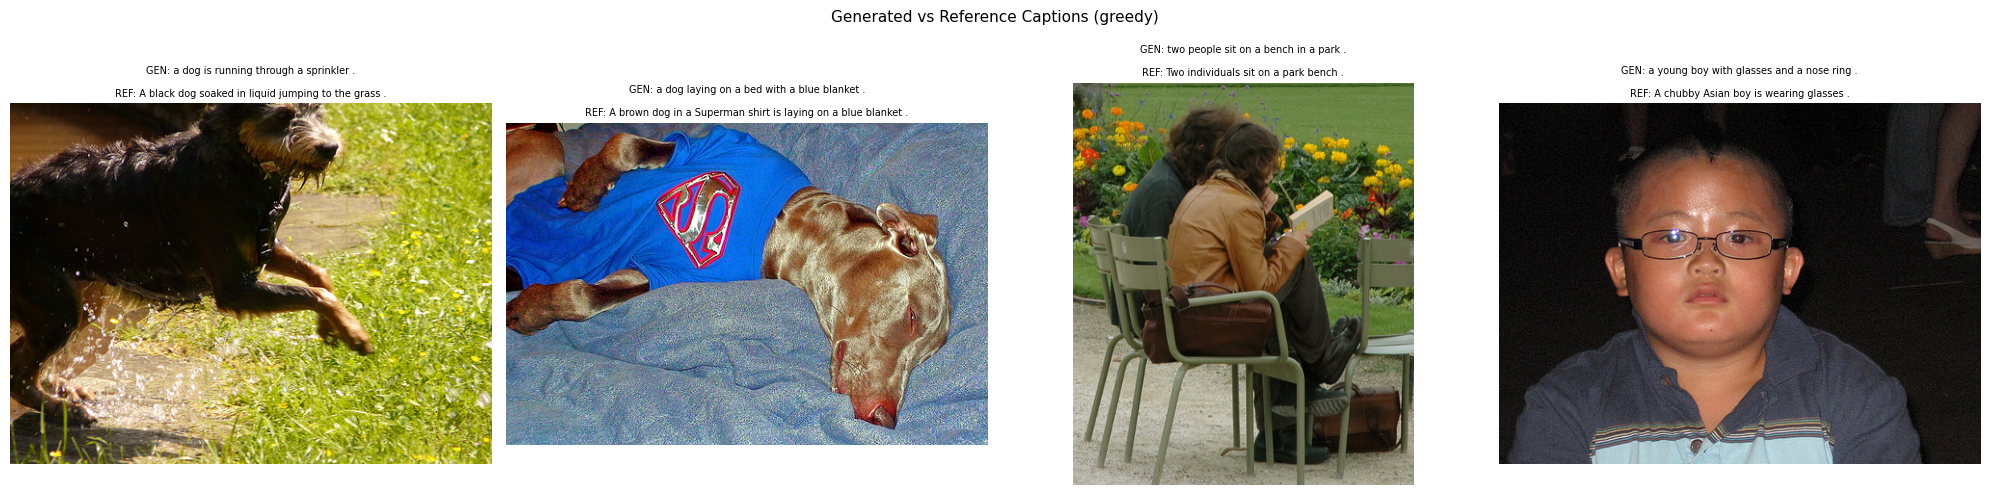

In [89]:
@torch.no_grad()
def generate_greedy(model, image: torch.Tensor, max_new_tokens: int = 30) -> str:
    """Generate one caption via greedy decoding for a quick sanity check."""
    model.eval()
    image   = image.unsqueeze(0).to(DEVICE)
    memory  = model.encode(image)

    tokens  = [BOS_ID]
    for _ in range(max_new_tokens):
        tgt    = torch.tensor([tokens], dtype=torch.long, device=DEVICE)
        logits = model.decode_step(tgt, memory)
        next_id = logits[0, -1, :].argmax().item()
        if next_id == EOS_ID:
            break
        tokens.append(next_id)

    return tokenizer.decode(tokens[1:], skip_special_tokens=True)


# Load best weights, show 4 val-set examples
model.load_state_dict(torch.load(SAVE_DIR / 'best_model.pt', map_location=DEVICE))

sample_rows = val_df.drop_duplicates('image').sample(4, random_state=SEED)
fig, axes   = plt.subplots(1, 4, figsize=(20, 5))

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    raw_img = Image.open(IMAGES_DIR / row['image']).convert("RGB")
    tensor  = val_transform(raw_img)
    caption = generate_greedy(model, tensor)

    ref_caps = val_df[val_df['image'] == row['image']]['caption'].tolist()
    ax.imshow(raw_img)
    ax.set_title(f"GEN: {caption}\n\nREF: {ref_caps[0]}", fontsize=7, wrap=True)
    ax.axis('off')

plt.suptitle('Generated vs Reference Captions (greedy)', fontsize=11)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'caption_examples.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Save Artifacts

In [90]:
# Save tokenizer (GPT-2 BPE — needed by inference.ipynb)
tokenizer.save_pretrained(str(SAVE_DIR / 'tokenizer'))
print("Saved tokenizer/")

# Save model config
model_config = {
    'clip_model_name':  CLIP_MODEL_NAME,
    'clip_pretrained':  CLIP_PRETRAINED,
    'clip_dim':         VISUAL_DIM,
    'gpt2_name':        'gpt2',
    'vocab_size':       VOCAB_SIZE,
    'n_xattn_heads':    8,
    'dropout':          0.1,
    'img_size':         IMG_SIZE,
    'max_seq_len':      MAX_SEQ_LEN,
    'pad_id':           PAD_ID,
    'bos_id':           BOS_ID,
    'eos_id':           EOS_ID,
}
with open(SAVE_DIR / 'model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)
print("Saved model_config.json")

# Save full checkpoint for resuming
torch.save({
    'epoch':           epoch,
    'model_state':     model.state_dict(),
    'optimizer_state': optimizer.state_dict(),
    'best_val_loss':   best_val_loss,
    'history':         history,
}, SAVE_DIR / 'last_checkpoint.pt')
print("Saved last_checkpoint.pt")

with open(SAVE_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f)
print("Saved training_history.json")

print("\nAll artifacts saved to:", SAVE_DIR)
print("  best_model.pt          — best weights (lowest val loss)")
print("  last_checkpoint.pt     — full checkpoint for resuming")
print("  tokenizer/             — GPT-2 BPE tokenizer for inference.ipynb")
print("  model_config.json      — architecture config for inference.ipynb")
print("  training_history.json  — per-epoch metrics")
print("  training_curves.png    — loss, perplexity & accuracy plots")
print("  caption_examples.png   — sample generated vs reference captions")


Saved tokenizer/
Saved model_config.json
Saved last_checkpoint.pt
Saved training_history.json

All artifacts saved to: /kaggle/working
  best_model.pt          — best weights (lowest val loss)
  last_checkpoint.pt     — full checkpoint for resuming
  tokenizer/             — GPT-2 BPE tokenizer for inference.ipynb
  model_config.json      — architecture config for inference.ipynb
  training_history.json  — per-epoch metrics
  training_curves.png    — loss, perplexity & accuracy plots
  caption_examples.png   — sample generated vs reference captions
